in scikit learn we have diff types of transformer such as function transformer and power transformer we use these transformer to convert our skewed data 

into normal distribution 


In [6]:
#in function transformer we have following :-
 # 1) Log transformer (used to convert right skewed data to normal distribution )
  # 2) square transformer (used to convert left skewed data into normal distribution )
  # 3) square root transformer  
  # NOTE:- WE CANNOT USE LOG TRANSFORMER IN CASE OF -VE VALUES AS LOG OF -VE VALUES IS NOT POSSIBLE 

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.tree  import DecisionTreeClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import accuracy_score
from sklearn.compose import ColumnTransformer
import scipy.stats as stats


In [11]:
df= pd.read_csv(r"C:\Users\LENOVO\Desktop\machine learnig\FEATURE_ENGINEERING\train.csv")
if not df.empty:
    print("data loaded sucessfully")
    print(df.columns)
df["Age"].fillna(df["Age"].mean(),inplace=True)
print(df.head())

data loaded sucessfully
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')
   PassengerId  Survived  Pclass  ...     Fare Cabin  Embarked
0            1         0       3  ...   7.2500   NaN         S
1            2         1       1  ...  71.2833   C85         C
2            3         1       3  ...   7.9250   NaN         S
3            4         1       1  ...  53.1000  C123         S
4            5         0       3  ...   8.0500   NaN         S

[5 rows x 12 columns]


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15072\2761808940.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(),inplace=True)


In [13]:
X= df[["Age","Fare"]]
y=df.Survived

In [14]:
X_train ,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15072\2888751792.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'])


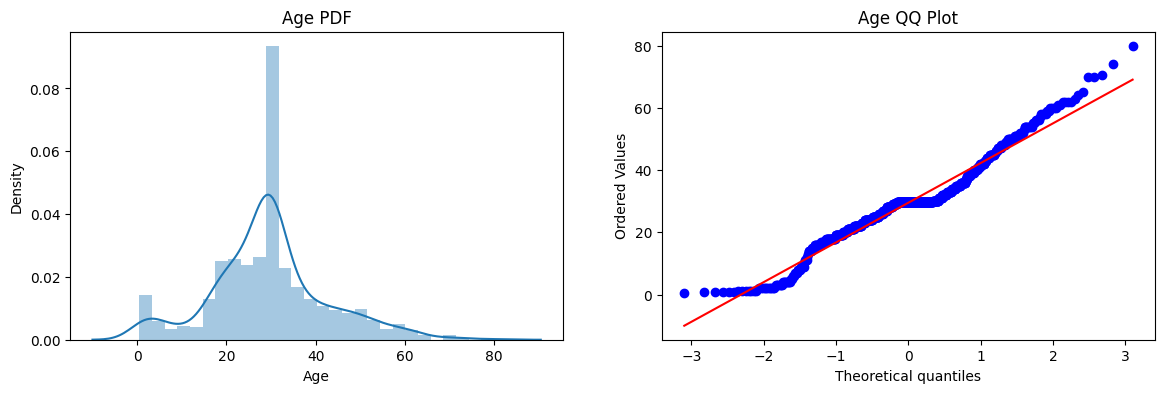

In [17]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Age'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15072\2048488742.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Fare'])


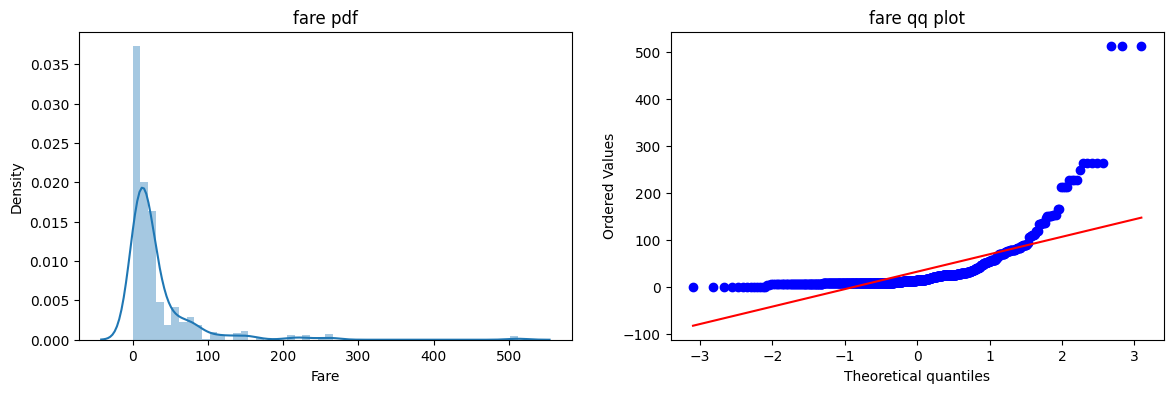

In [18]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Fare'])
plt.title('fare pdf')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('fare qq plot')

plt.show()

In [23]:
tnf = FunctionTransformer(np.log1p, validate=False)

# Apply transformation and assign back
X_train["Fare"] = tnf.transform(X_train[["Fare"]])

print(X_train["Fare"].head())


331    3.384390
733    2.639057
382    2.188856
704    2.180892
813    3.474293
Name: Fare, dtype: float64
